1. Import modules and set paths

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
processed_path = Path("../data/processed")


2.Load processed CSVs

In [2]:
tsla = pd.read_csv(processed_path / "TSLA_cleaned.csv", index_col=0, parse_dates=True)
bnd  = pd.read_csv(processed_path / "BND_cleaned.csv", index_col=0, parse_dates=True)
spy  = pd.read_csv(processed_path / "SPY_cleaned.csv", index_col=0, parse_dates=True)


3. Plot Adjusted Close / Close price trends

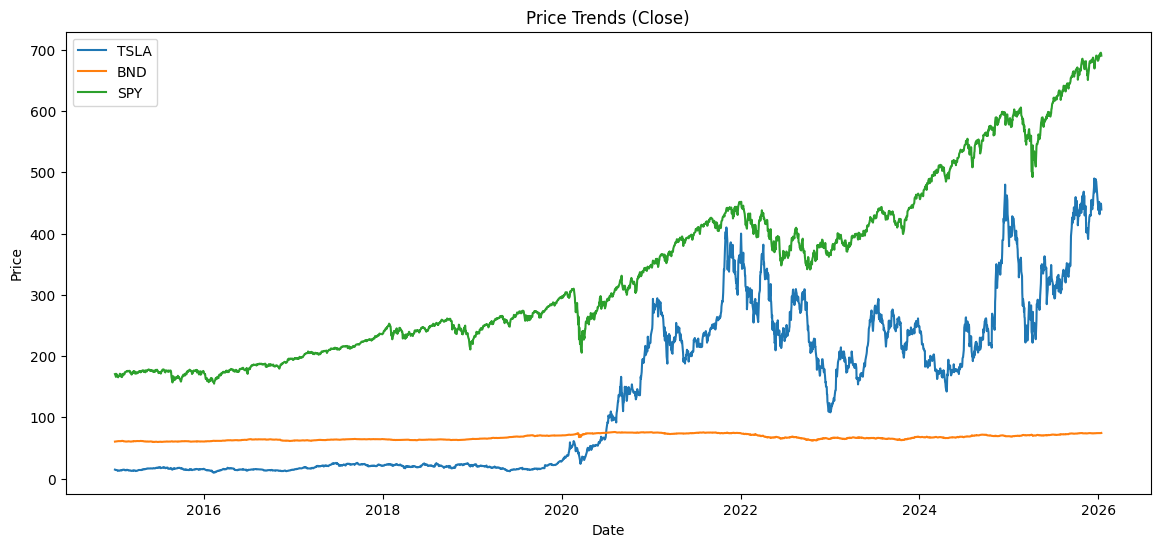

In [3]:
plt.figure(figsize=(14,6))
plt.plot(tsla['Close'], label='TSLA')
plt.plot(bnd['Close'], label='BND')
plt.plot(spy['Close'], label='SPY')
plt.title("Price Trends (Close)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


4. Histogram of daily returns

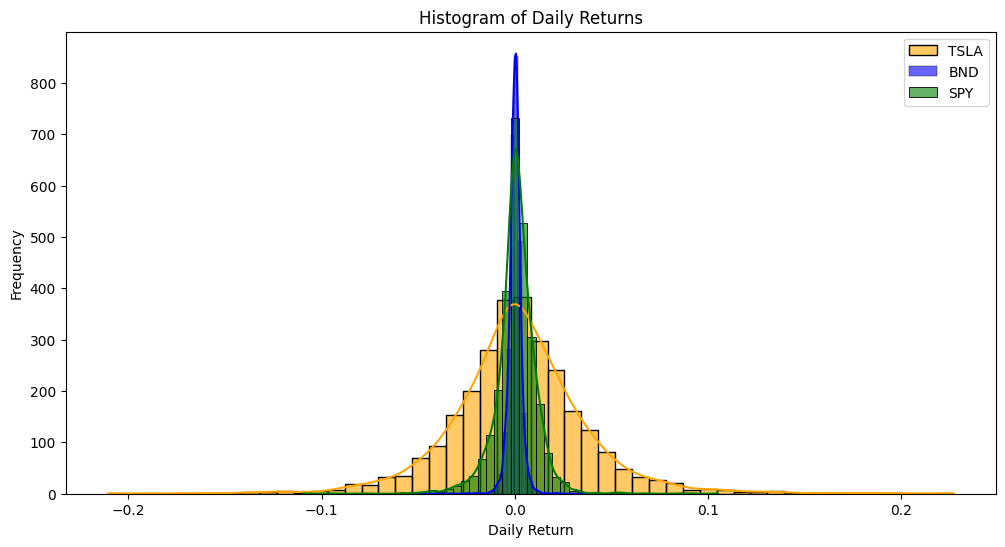

In [7]:
plt.figure(figsize=(12,6))
sns.histplot(tsla['Return'], bins=50, kde=True, color='orange', label='TSLA', alpha=0.6)
sns.histplot(bnd['Return'], bins=50, kde=True, color='blue', label='BND', alpha=0.6)
sns.histplot(spy['Return'], bins=50, kde=True, color='green', label='SPY', alpha=0.6)
plt.title("Histogram of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()


5. Rolling Mean (Trend) vs Rolling Std (Volatility)

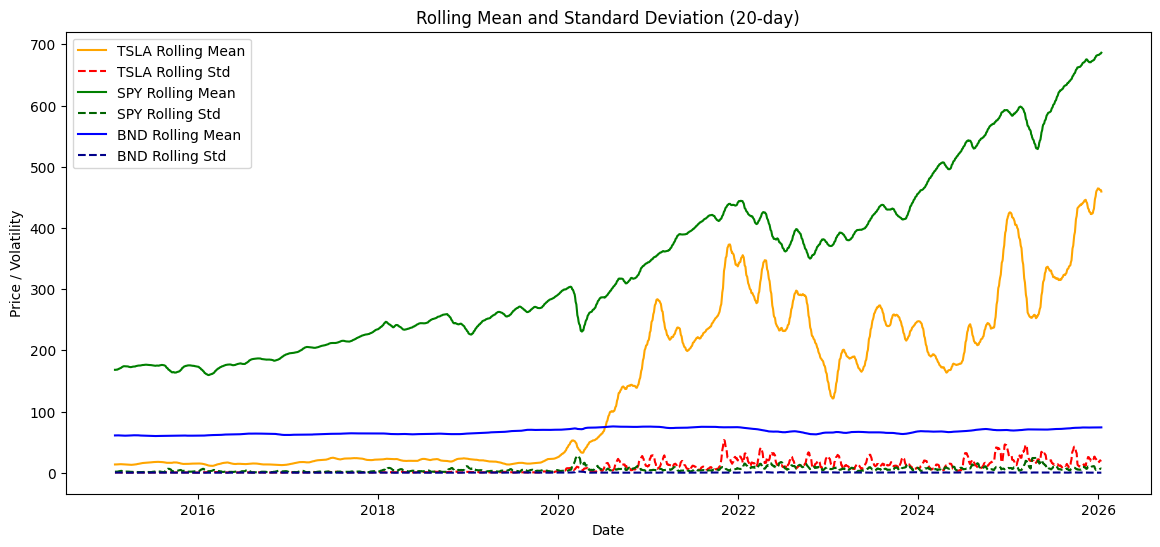

In [8]:
window = 20  # 20-day rolling window

plt.figure(figsize=(14,6))
plt.plot(tsla['Close'].rolling(window).mean(), label='TSLA Rolling Mean', color='orange')
plt.plot(tsla['Close'].rolling(window).std(), label='TSLA Rolling Std', color='red', linestyle='--')

plt.plot(spy['Close'].rolling(window).mean(), label='SPY Rolling Mean', color='green')
plt.plot(spy['Close'].rolling(window).std(), label='SPY Rolling Std', color='darkgreen', linestyle='--')

plt.plot(bnd['Close'].rolling(window).mean(), label='BND Rolling Mean', color='blue')
plt.plot(bnd['Close'].rolling(window).std(), label='BND Rolling Std', color='darkblue', linestyle='--')

plt.title("Rolling Mean and Standard Deviation (20-day)")
plt.xlabel("Date")
plt.ylabel("Price / Volatility")
plt.legend()
plt.show()


6. Plot daily returns

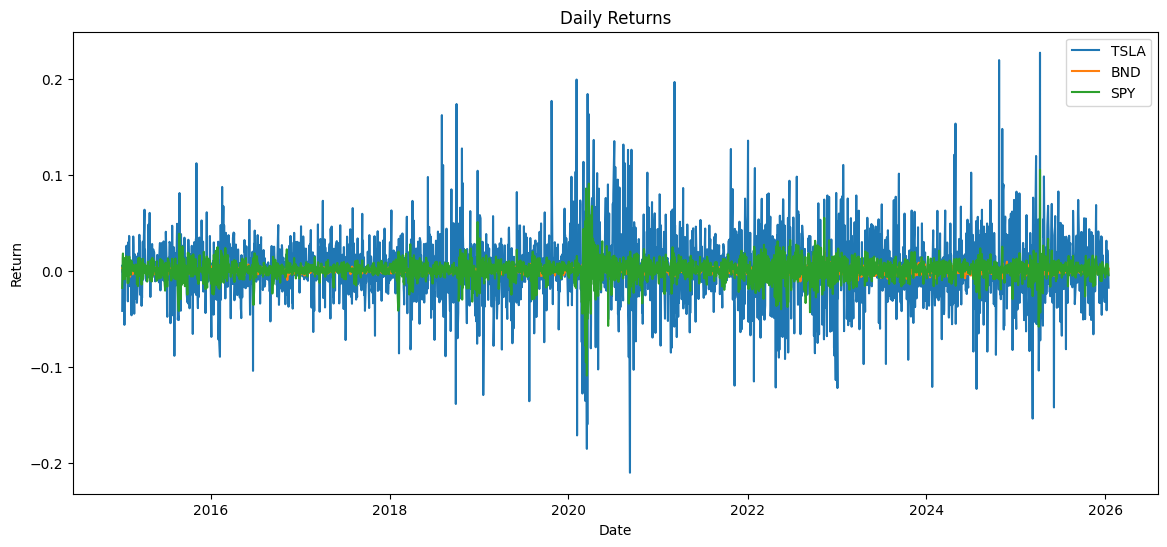

In [4]:
plt.figure(figsize=(14,6))
plt.plot(tsla['Return'], label='TSLA')
plt.plot(bnd['Return'], label='BND')
plt.plot(spy['Return'], label='SPY')
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()


5. Plot rolling volitility ( 20 days)

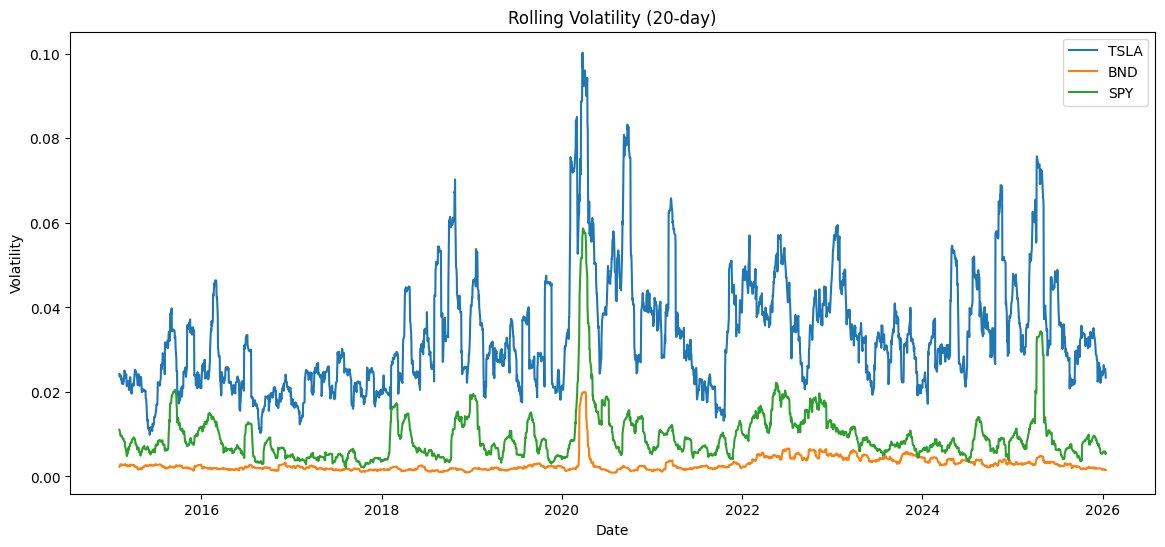

In [5]:
plt.figure(figsize=(14,6))
plt.plot(tsla['RollingVol'], label='TSLA')
plt.plot(bnd['RollingVol'], label='BND')
plt.plot(spy['RollingVol'], label='SPY')
plt.title("Rolling Volatility (20-day)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()


In [6]:
plot_path = Path("../plots")
plot_path.mkdir(exist_ok=True)

plt.savefig(plot_path / "price_trends.png")
plt.savefig(plot_path / "daily_returns.png")
plt.savefig(plot_path / "rolling_volatility.png")


<Figure size 640x480 with 0 Axes>

--- TSLA Data Info ---
<class 'pandas.DataFrame'>
DatetimeIndex: 2755 entries, 2015-02-02 to 2026-01-14
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Close       2755 non-null   float64
 1   High        2755 non-null   float64
 2   Low         2755 non-null   float64
 3   Open        2755 non-null   float64
 4   Volume      2755 non-null   int64  
 5   Return      2755 non-null   float64
 6   RollingVol  2755 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 172.2 KB
None
                Close       High        Low       Open    Volume    Return  \
Date                                                                         
2015-02-02  14.062667  14.130000  13.553333  13.598000  62238000  0.036051   
2015-02-03  14.557333  14.691333  14.084667  14.214667  72393000  0.035176   
2015-02-04  14.570000  14.765333  14.453333  14.552667  49581000  0.000870   
2015-02-05  14.732667  15.032000  14.642667  14.

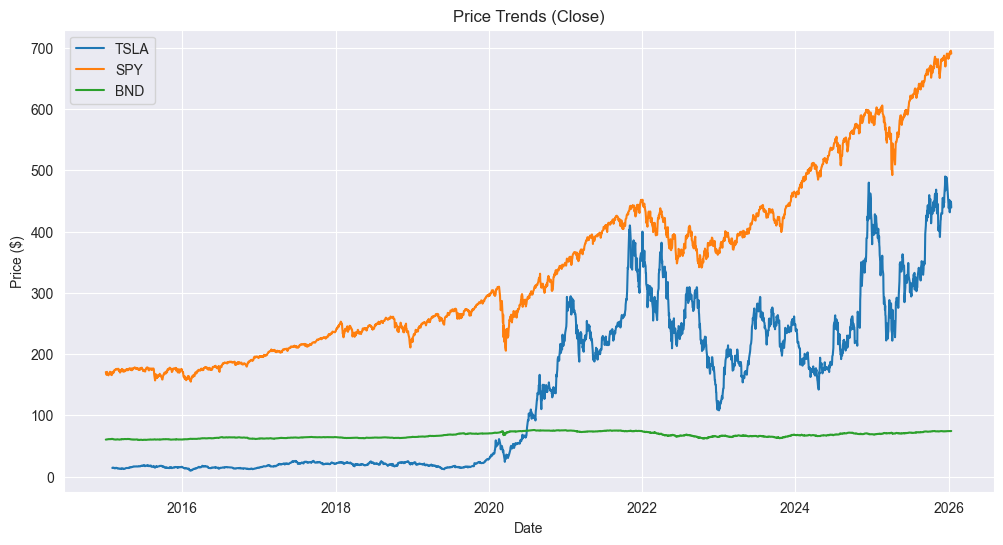

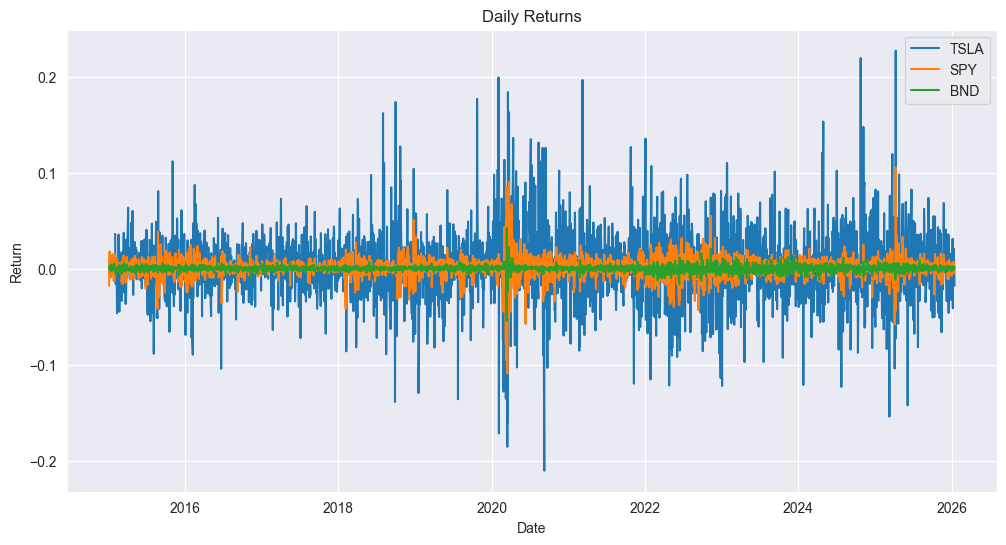

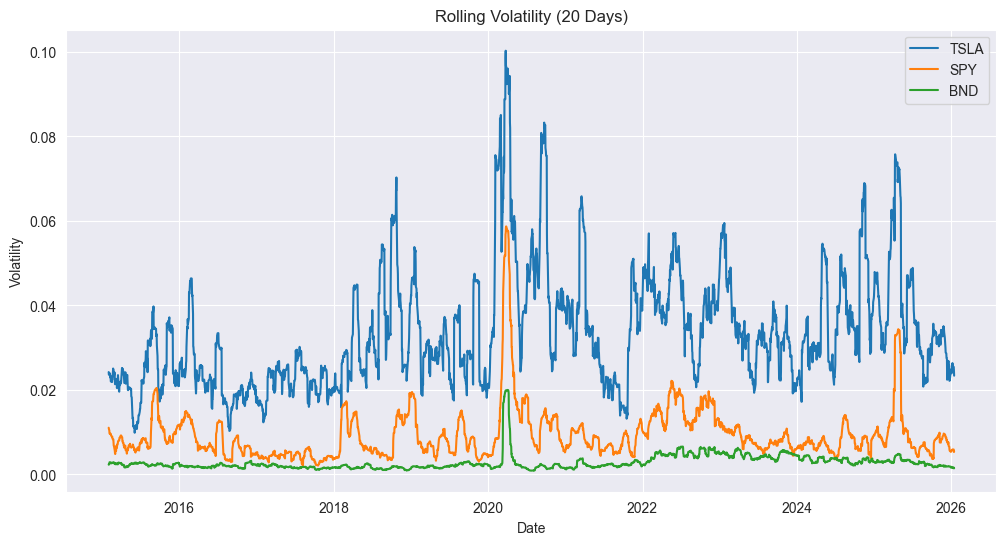

TSLA normalized data saved
SPY normalized data saved
BND normalized data saved


In [4]:
# notebooks/eda.py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# 1. Set Paths & Load Data
# -----------------------------
processed_path = Path("../data/processed")

tsla = pd.read_csv(processed_path / "TSLA_cleaned.csv", index_col=0, parse_dates=True)
spy  = pd.read_csv(processed_path / "SPY_cleaned.csv", index_col=0, parse_dates=True)
bnd  = pd.read_csv(processed_path / "BND_cleaned.csv", index_col=0, parse_dates=True)

data = {"TSLA": tsla, "SPY": spy, "BND": bnd}

# -----------------------------
# 2. Inspect Data
# -----------------------------
for ticker, df in data.items():
    print(f"--- {ticker} Data Info ---")
    print(df.info())
    print(df.head(), "\n")

# -----------------------------
# 3. Outlier Detection for Returns
# -----------------------------
for ticker, df in data.items():
    # Using z-score to flag extreme daily returns
    df["Return_zscore"] = (df["Return"] - df["Return"].mean()) / df["Return"].std()
    outliers = df[np.abs(df["Return_zscore"]) > 3]
    print(f"{ticker} outliers (|z|>3): {len(outliers)} rows\n")

# -----------------------------
# 4. Normalize/Scale Price Columns
# -----------------------------
scaler = MinMaxScaler()

for ticker, df in data.items():
    df["Close_scaled"] = scaler.fit_transform(df[["Close"]])
    df["Return_scaled"] = scaler.fit_transform(df[["Return"]])
    df["RollingVol_scaled"] = scaler.fit_transform(df[["RollingVol"]])

# -----------------------------
# 5. Visualizations
# -----------------------------
sns.set_style("darkgrid") 

# 5.1 Price Trends
plt.figure(figsize=(12,6))
for ticker, df in data.items():
    plt.plot(df.index, df["Close"], label=ticker)
plt.title("Price Trends (Close)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()
# PLACEHOLDER: Insert description for the plot in the report

# 5.2 Daily Returns
plt.figure(figsize=(12,6))
for ticker, df in data.items():
    plt.plot(df.index, df["Return"], label=ticker)
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()
# PLACEHOLDER: Insert description for the plot in the report

# 5.3 Rolling Volatility (20 days)
plt.figure(figsize=(12,6))
for ticker, df in data.items():
    plt.plot(df.index, df["RollingVol"], label=ticker)
plt.title("Rolling Volatility (20 Days)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()
# PLACEHOLDER: Insert description for the plot in the report

# -----------------------------
# 6. Save Normalized Data (Optional)
# -----------------------------
for ticker, df in data.items():
    df.to_csv(processed_path / f"{ticker}_normalized.csv")
    print(f"{ticker} normalized data saved")


TSLA outliers (|z|>3): 44 rows
SPY outliers (|z|>3): 39 rows
BND outliers (|z|>3): 32 rows


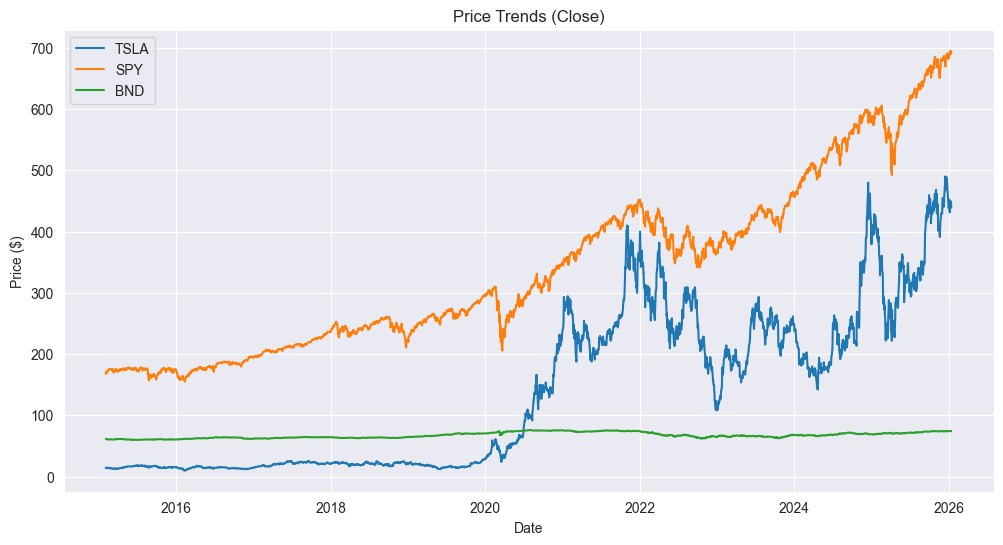

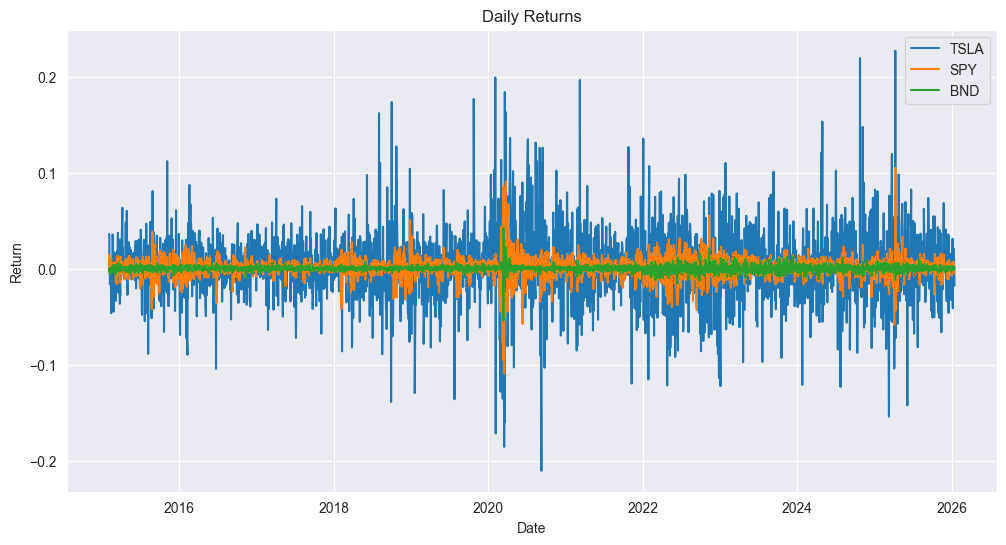

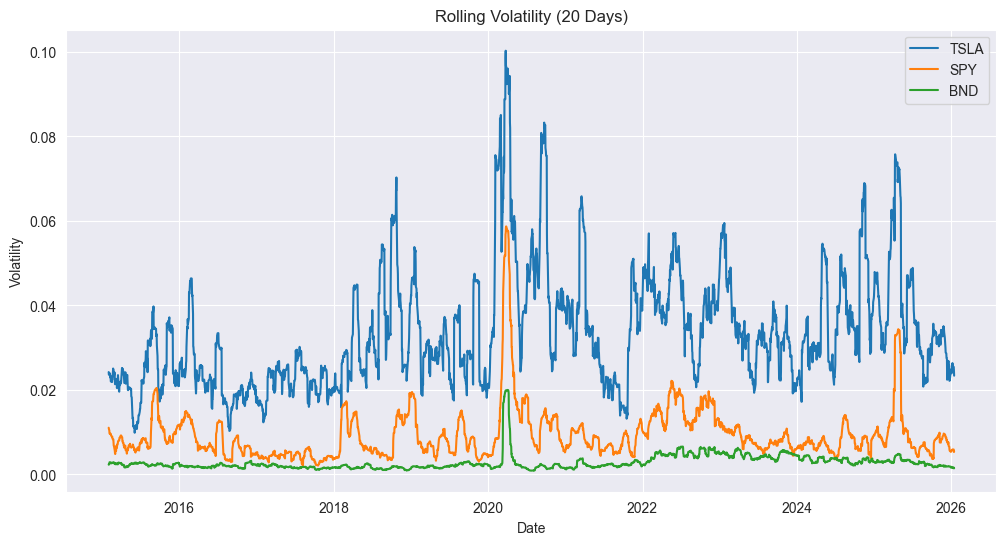

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# -----------------------------
# 1. Load Processed Data
# -----------------------------
processed_path = Path("../data/processed")

tsla = pd.read_csv(processed_path / "TSLA_cleaned.csv", index_col=0, parse_dates=True)
spy  = pd.read_csv(processed_path / "SPY_cleaned.csv", index_col=0, parse_dates=True)
bnd  = pd.read_csv(processed_path / "BND_cleaned.csv", index_col=0, parse_dates=True)

data = {"TSLA": tsla, "SPY": spy, "BND": bnd}

# -----------------------------
# 2. Drop NaNs from Returns & RollingVol
# -----------------------------
for ticker, df in data.items():
    df.dropna(subset=["Return", "RollingVol"], inplace=True)

# -----------------------------
# 3. Outlier Detection
# -----------------------------
for ticker, df in data.items():
    df["Return_zscore"] = (df["Return"] - df["Return"].mean()) / df["Return"].std()
    outliers = df[np.abs(df["Return_zscore"]) > 3]
    print(f"{ticker} outliers (|z|>3): {len(outliers)} rows")

# -----------------------------
# 4. Normalization
# -----------------------------
scaler = MinMaxScaler()
for ticker, df in data.items():
    df["Close_scaled"] = scaler.fit_transform(df[["Close"]])
    df["Return_scaled"] = scaler.fit_transform(df[["Return"]])
    df["RollingVol_scaled"] = scaler.fit_transform(df[["RollingVol"]])

# -----------------------------
# 5. Plotting
# -----------------------------
sns.set_style("darkgrid")  # Use Seaborn style

# 5.1 Price
plt.figure(figsize=(12,6))
for ticker, df in data.items():
    plt.plot(df.index, df["Close"], label=ticker)
plt.title("Price Trends (Close)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

# 5.2 Daily Returns
plt.figure(figsize=(12,6))
for ticker, df in data.items():
    plt.plot(df.index, df["Return"], label=ticker)
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

# 5.3 Rolling Volatility
plt.figure(figsize=(12,6))
for ticker, df in data.items():
    plt.plot(df.index, df["RollingVol"], label=ticker)
plt.title("Rolling Volatility (20 Days)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()
